## 0. Setup

In [ ]:
### Main Modules
import os 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import fastparquet

### Models
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression

### Metrics and calibrarion
from sklearn.metrics import (f1_score,accuracy_score,recall_score,precision_score,roc_auc_score,roc_curve,precision_recall_curve,confusion_matrix)

### Font sizes
plt.rcParams.update({
    'font.size': 14,          # Tamaño de fuente general
    'axes.labelsize': 16,     # Tamaño de las etiquetas de los ejes 
    'axes.titlesize': 16,     # Tamaño de los títulos de las facetas
    'xtick.labelsize': 12,    # Tamaño de los números en el eje X
    'ytick.labelsize': 12     # Tamaño de los números en el eje Y
})

## 1. Cargar datos 

In [37]:
### Cargar datos
train = pd.read_csv('../../01_data/output/01_original_data_train.csv')
test = pd.read_csv('../../01_data/output/01_original_data_test.csv')
validation = pd.read_csv('../../01_data/output/01_original_data_validation.csv')

### Limpiar dependiente
for df in [train,test,validation]:
    df["pobre"] = np.where(df["pobre"] == "Yes", 1, 0) 

### Split datos
train_x, train_y = train.drop(columns=["id","pobre"]), train["pobre"]
validation_x, validation_y = validation.drop(columns=["id","pobre"]), validation["pobre"]
test_x, test_y = test.drop(columns=["id","pobre"]), test["pobre"]

### Crear lista con 10 variables mas importantes del modelo grande (SHAP)
top_10_predictors = [
    "oc_household_average", "arriendo", "regimen_salud_1_household_average",
    "tipo_propiedad_vivienda_hogar", "ocupado_horas_trabajadas_normalmente_household_working",
    "numero_personas_unidad_gasto", "tipo_propiedad_vivienda_hogar_3",
    "ocupado_tamano_de_la_empresa_9_household_working", 
    "maximo_nivel_educativo_6_household_average", "ocupado_relab_4_household_working"
]

### Test ids
test_ids = test['id']

## 2. Hacer predicciones

#### 2.1 Crear semillas para reproducibilidad

In [38]:
# 1. Generar 5000 numeros, con distribucion normal. Convertir a enteros y remover duplicados
unique_seeds = np.unique(np.abs(np.random.normal(loc=50000, scale=15000, size=5000)).astype(int))

# Mantener los ultimos 100 numeros generados y convertirlos a lista
seeds = unique_seeds[:100].tolist()

#### 2.2 Experimento de robustez para el modelo restringido (10 Variables)

In [39]:
### 1. Semillas para reproducibilidad
seeds
outputs = []

for seed in seeds:
    # 1. Bootstrap de los datos de entrenamiento 
    train_x_boot = train_x.sample(frac=1.0, replace=True, random_state=seed)
    train_y_boot = train_y.loc[train_x_boot.index]

    # 2. Arquitectura del modelo
    model = XGBClassifier(
        n_estimators=500,
        max_depth=7,
        learning_rate=0.04,
        min_child_weight=25,
        gamma=0,
        colsample_bytree=0.6,
        subsample=0.8,
        random_state=seed,
        eval_metric='logloss')

    # 3. Entrenar modelo
    model.fit(X=train_x_boot[top_10_predictors], y=train_y_boot)

    # 4. Computar predicciones en el conjunto de validacion
    val_probs = model.predict_proba(validation_x[top_10_predictors])[:, 1]

    # --- Calcular puntos de corte ---
    precision, recall, pr_thresholds = precision_recall_curve(validation_y, val_probs)

    # Calcular el F1 para cada punto de corte
    with np.errstate(divide='ignore', invalid='ignore'):
        val_f1_scores = np.nan_to_num((2 * precision * recall) / (precision + recall))

    # Hallar el indice con el mayor F1
    best_f1_idx = np.argmax(val_f1_scores)

    # Computar el punto de corte
    rfThreshF1 = pr_thresholds[best_f1_idx] if best_f1_idx < len(pr_thresholds) else 1.0

    # 4. Predecir en el conjunto de entrenamietno usando el punto de corte optimizado para F1
    test_probs = model.predict_proba(test_x[top_10_predictors])[:, 1]
    test_preds_binary = (test_probs >= rfThreshF1).astype(int)

    # Gaurdar resultados en un dataframe 
    predicted_value_test = pd.DataFrame({
        'seed': seed,                 # <--- ADDED: Track which seed this came from
        'prob_Yes': test_probs,
        'predicted_class': test_preds_binary,
        'actual_pobre': test_y,
    })
    
    # --- Guardar el resultado
    outputs.append(predicted_value_test)
    
# --- Concatenar ---

# Combine all predictions from all seeds into a single DataFrame
all_predictions_top_10 = pd.concat(outputs, ignore_index=True)

# Export the master prediction dataset to a CSV file
all_predictions_top_10.to_parquet('../../06_uncertainy/output/01_sub_model_uncertainty_predicted_values.parquet',engine="fastparquet")


KeyboardInterrupt: 

#### 2.2 Experimento de robustez para el modelo completo (152 Variables)

In [ ]:
### 1. Semillas para reproducibilidad
seeds
outputs = []

for seed in seeds:
    # 1. Bootstrap de los datos de entrenamiento 
    train_x_boot = train_x.sample(frac=1.0, replace=True, random_state=seed)
    train_y_boot = train_y.loc[train_x_boot.index]

    # 2. Arquitectura del modelo
    model = XGBClassifier(
        n_estimators=500,
        max_depth=7,
        learning_rate=0.04,
        min_child_weight=25,
        gamma=0,
        colsample_bytree=0.6,
        subsample=0.8,
        random_state=seed,
        eval_metric='logloss')

    # 3. Entrenar modelo
    model.fit(X=train_x_boot, y=train_y_boot)

    # 4. Computar predicciones en el conjunto de validacion
    val_probs = model.predict_proba(validation_x)[:, 1]

    # --- Calcular puntos de corte ---
    precision, recall, pr_thresholds = precision_recall_curve(validation_y, val_probs)

    # Calcular el F1 para cada punto de corte
    with np.errstate(divide='ignore', invalid='ignore'):
        val_f1_scores = np.nan_to_num((2 * precision * recall) / (precision + recall))

    # Hallar el indice con el mayor F1
    best_f1_idx = np.argmax(val_f1_scores)

    # Computar el punto de corte
    rfThreshF1 = pr_thresholds[best_f1_idx] if best_f1_idx < len(pr_thresholds) else 1.0

    # 4. Predecir en el conjunto de entrenamietno usando el punto de corte optimizado para F1
    test_probs = model.predict_proba(test_x)[:, 1]
    test_preds_binary = (test_probs >= rfThreshF1).astype(int)

    # Gaurdar resultados en un dataframe 
    predicted_value_test = pd.DataFrame({
        'seed': seed,                 # <--- ADDED: Track which seed this came from
        'prob_Yes': test_probs,
        'predicted_class': test_preds_binary,
        'actual_pobre': test_y,
    })
    
    # --- Guardar el resultado
    outputs.append(predicted_value_test)
    
# --- Concatenar ---

# Combine all predictions from all seeds into a single DataFrame
all_predictions_main_model = pd.concat(outputs, ignore_index=True)

# Export the master prediction dataset to a CSV file
all_predictions_main_model.to_parquet('../../06_uncertainy/output/01_model_uncertainty_predicted_values.parquet',engine="fastparquet")

## 3. Computar métricas de rendimiento

In [40]:
### importar datos
all_predictions_main_model = pd.read_parquet('../../06_uncertainy/output/01_model_uncertainty_predicted_values.parquet',engine='fastparquet')
all_predictions_top_10 = pd.read_parquet('../../06_uncertainy/output/01_sub_model_uncertainty_predicted_values.parquet',engine="fastparquet")

In [48]:
# Helper function to compute all metrics for a single seed group
def compute_metrics(group):
    # scikit-learn metrics expect numeric formats for binary classification
    y_true = group['actual_pobre'].astype(int)
    y_pred = group['predicted_class'].astype(int)
    y_prob = group['prob_Yes']
    
    return pd.Series({
        'f1': f1_score(y_true, y_pred),
    })

### 3.1 Modelo Principal (P = 152)

In [49]:
### Computar estadísticas y unir datos

# Aplicar por semilla by seed, computar las metricas, and reset index
metrics_wide_main_model = all_predictions_main_model.groupby('seed').apply(compute_metrics).reset_index()

# Pivotear el dataframe
data_main_model = metrics_wide_main_model.melt(id_vars='seed', var_name='.metric', value_name='.estimate')

<positron-console-cell-49>:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


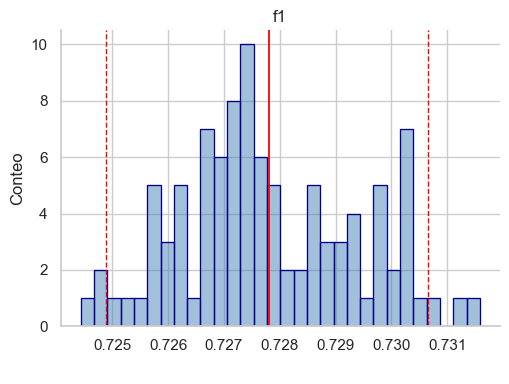

In [53]:
# Calcular media y desviación estándar para cada metrica
summary_stats = data_main_model.groupby('.metric')['.estimate'].agg(
    mean_val='mean', 
    val_lower_bound=lambda x: x.quantile(0.025),
    val_upper_bound=lambda x: x.quantile(0.975)
).reset_index()

# Crear base del gráfico
g = sns.FacetGrid(data_main_model, col='.metric', col_wrap=3, sharex=False, height=4, aspect=1.2)

g.set_titles(col_template="{col_name}")

# Mapear el histograma
g.map_dataframe(sns.histplot, x='.estimate', fill=True, color='steelblue', 
                edgecolor='darkblue', alpha=0.5, bins=30)

# Iterar por cada panel del gráfico 
for ax, metric_name in zip(g.axes.flat, g.col_names):
    # Usar estadísticas precaculculadas
    stats = summary_stats[summary_stats['.metric'] == metric_name].iloc[0]
    mean_val = stats['mean_val']
    val_lower_bound = stats['val_lower_bound']
    val_upper_bound = stats['val_upper_bound']

    # Linea roja solida para le media
    ax.axvline(mean_val, color='red', linestyle='solid', linewidth=1.3)
    
    # Linea roja punteada para la media +/- desviacion estándar
    ax.axvline(val_lower_bound, color='red', linestyle='dashed', linewidth=1)
    ax.axvline(val_upper_bound, color='red', linestyle='dashed', linewidth=1)
    
    # Clean up axis labels
    ax.set_xlabel(" ")
    ax.set_ylabel("Conteo")

# Apply minimal theme layout equivalent
sns.set_theme(style="whitegrid")
plt.tight_layout()
plt.savefig("../../06_uncertainy//output/01_uncertainty_main_model.pdf", dpi=300, bbox_inches="tight")
plt.show()

### 3.2 Modelo Restringido (P = 10)

In [54]:
### Computar estadísticas y unir datos

# Aplicar por semilla by seed, computar las metricas, and reset index
metrics_wide_top_10 = all_predictions_top_10.groupby('seed').apply(compute_metrics).reset_index()

# Pivotear el dataframe
data_top_10 = metrics_wide_top_10.melt(id_vars='seed', var_name='.metric', value_name='.estimate')

<positron-console-cell-54>:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.


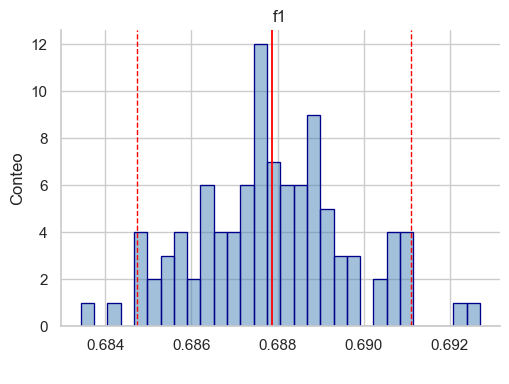

In [55]:
# Calcular media y desviación estándar para cada metrica
summary_stats_top_10 = data_top_10.groupby('.metric')['.estimate'].agg(
    mean_val='mean', 
    val_lower_bound=lambda x: x.quantile(0.025),
    val_upper_bound=lambda x: x.quantile(0.975)
).reset_index()

# Crear base del gráfico
g = sns.FacetGrid(data_top_10, col='.metric', col_wrap=3, sharex=False, height=4, aspect=1.2)

g.set_titles(col_template="{col_name}")

# Mapear el histograma
g.map_dataframe(sns.histplot, x='.estimate', fill=True, color='steelblue', 
                edgecolor='darkblue', alpha=0.5, bins=30)

# Iterar por cada panel del gráfico 
for ax, metric_name in zip(g.axes.flat, g.col_names):
    # Usar estadísticas precaculculadas
    stats = summary_stats_top_10[summary_stats['.metric'] == metric_name].iloc[0]
    mean_val = stats['mean_val']
    val_lower_bound = stats['val_lower_bound']
    val_upper_bound = stats['val_upper_bound']

    # Linea roja solida para le media
    ax.axvline(mean_val, color='red', linestyle='solid', linewidth=1.3)
    
    # Linea roja punteada para la media +/- desviacion estándar
    ax.axvline(val_lower_bound, color='red', linestyle='dashed', linewidth=1)
    ax.axvline(val_upper_bound, color='red', linestyle='dashed', linewidth=1)
    
    # Clean up axis labels
    ax.set_xlabel(" ")
    ax.set_ylabel("Conteo")

# Apply minimal theme layout equivalent
sns.set_theme(style="whitegrid")
plt.tight_layout()
plt.savefig("../../06_uncertainy//output/01_uncertainty_top_10_model.pdf", dpi=300, bbox_inches="tight")
plt.show()